In [1]:
import time
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize 
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, precision_score, recall_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut, cross_val_predict, GridSearchCV
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectFromModel
from itertools import product
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel


In [2]:
# make a base folder to store the plots
base_folder = f"results/"
os.makedirs(base_folder, exist_ok=True)

In [3]:
#random seed
np.random.seed(22)

In [4]:
#read the data 
datax   = pd.read_csv("Train_call.tsv",      sep="\t", header=0)
datay   = pd.read_csv("Train_clinical.tsv",  sep="\t", header=0)

#make into long dataframe
datax_long = pd.melt(
    datax,
    id_vars=["Chromosome","Start","End","Nclone"],    # vaste kolommen
    var_name="Sample",
    value_name="Value"
)

#merge with the classes of the subtypes of cancer
merged = pd.merge(
    datax_long,
    datay,                    
    on="Sample",
    how="inner"            
)

#make unique genoimic segment into one variable
merged["GenomicSegment"] = (
    "Seg_" + merged["Chromosome"].astype(str)
          + "_" + merged["Start"].astype(str)
          + "_" + merged["End"].astype(str)
)

# pivot long into wide format 
wide_data = merged.pivot_table(
    index=["Sample","Subgroup"],
    columns="GenomicSegment",
    values="Value"
).reset_index()


# drop sample and subgroep and make subgroup the target value
X = wide_data.drop(columns=["Sample","Subgroup"])
subgroup_cat = wide_data["Subgroup"].astype("category") # for the code2lable
y = subgroup_cat.cat.codes

In [5]:
class CorrSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        # Initialize selector with a correlation cutoff threshold
        self.threshold = threshold

    def fit(self, X, y=None):
        # Convert X to numpy array for corrcoef
        X = np.array(X)
        # compute absolute correlation matrix between features
        corr = np.abs(np.corrcoef(X, rowvar=False))
        # prepare a set to hold indices of features to drop
        drop = set()
        n = X.shape[1]  # number of features

        # loop over upper triangle of the correlation matrix
        for i in range(n):
            for j in range(i+1, n):
                # if two features are more correlated than threshold, mark j for dropping
                if corr[i, j] > self.threshold:
                    drop.add(j)

        # keep indices that were not marked for dropping
        self.keep_idx_ = [i for i in range(n) if i not in drop]
        return self

    def transform(self, X):
        # apply selection: return only the columns in keep_idx_
        return np.array(X)[:, self.keep_idx_]
        
# subclass to preserve DataFrame column names in SelectFromModel
class DataFrameSelectFromModel(SelectFromModel):
    def fit(self, X, y=None):
        # record column names if X is DataFrame
        if isinstance(X, pd.DataFrame):
            self._feature_names = X.columns
            X_in = X.values
        else:
            self._feature_names = None
            X_in = X
        super().fit(X_in, y)
        return self

    def transform(self, X):
        arr = super().transform(X.values if isinstance(X, pd.DataFrame) else X)
        if self._feature_names is not None:
            mask = self.get_support()
            cols = self._feature_names[mask]
            return pd.DataFrame(arr, columns=cols, index=X.index)
        return arr

In [6]:
############################################## rf hyperparmter grid

rf_param_grid = {
    'clf__n_estimators':      [50, 100, 200],
    'clf__max_depth':         [None, 5, 10],
    'clf__min_samples_split': [2, 5, 10]
}
############################################# feature selection grid
#rf importance 
rf_top_features  = [50, 100, 150]

#pca variance
pca_variance     = [0.85, 0.90, 0.95]

#correlation treshold
corr_thresholds  = [0.95, 0.90,0.85]

n_repeats       = 50                    # (7) Repeat entire 3-fold procedure this many times
outer_splits    = 3                     # (6) 3 equal parts for outer CV
inner_folds     = 10                   # (1) 10-fold inner CV to tune FS & HP

results = []
results_all_grid = []               # to store all inner CV possibiliets 243 in total

In [7]:
# start timer
t0 = time.time()

# ─────────────────────────────────────────────────────────────────────────────
# 7) Outer repetition: repeat the full 3-fold CV n_repeats times
# ─────────────────────────────────────────────────────────────────────────────
for rep in range(n_repeats):
    
    # 6) Outer 3-fold CV to split into three equal parts
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=22)
    
    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        # **Use positional indexing** on the DataFrame/Series
        X_train_outer = X.iloc[train_idx]
        X_test_outer  = X.iloc[test_idx]
        y_train_outer = y.iloc[train_idx]
        y_test_outer  = y.iloc[test_idx]
        
        # 1) Inner 10-fold CV on the 2/3 training portion to tune FS & HP
        inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=22)
        
        for fs_method in ['rf_imp', 'pca', 'corr']:
            
            # Build pipeline + parameter grid
            if fs_method == 'rf_imp':
                pipe = Pipeline([
                    ('scale', StandardScaler().set_output(transform="pandas")),
                    ('rf',   SelectFromModel(RandomForestClassifier(random_state=22),
                                             threshold=-np.inf)),
                    ('clf',   RandomForestClassifier(random_state=22))
                ])
                fs_param_name = 'rf__max_features'
                fs_param_values = rf_top_features
                param_grid = {fs_param_name: rf_top_features, **rf_param_grid}

            
            elif fs_method == 'pca':
                pipe = Pipeline([
                    ('scale', StandardScaler().set_output(transform="pandas")),
                    ('pca',   PCA()),
                    ('clf',   RandomForestClassifier(random_state=22))
                ])
                fs_param_name = 'pca__n_components'
                fs_param_values = pca_variance
                param_grid = {fs_param_name: pca_variance, **rf_param_grid}

            
            else: # corr
                pipe = Pipeline([
                    ('scale', StandardScaler().set_output(transform="pandas")),
                    ('corr',  CorrSelector()), 
                    ('clf',   RandomForestClassifier(random_state=22))
                ])
                fs_param_name = 'corr__threshold'
                fs_param_values = corr_thresholds
                param_grid = {fs_param_name: corr_thresholds, **rf_param_grid}

            
            
            # 2) Inner CV grid‐search: select best FS param + classifier HP
            grid = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                scoring='accuracy', n_jobs=-1)
            # Ensure X_train_outer is a DataFrame with column names
            grid.fit(X_train_outer, y_train_outer)

            #extract best model and best estimators 
            best_model  = grid.best_estimator_
            best_params = grid.best_params_
            
           # Store all inner grid-search results (not just best one)
            for i in range(len(grid.cv_results_['params'])):
                param_set = grid.cv_results_['params'][i]
                mean_score = grid.cv_results_['mean_test_score'][i]
            
                results_all_grid.append({
                    'repeat':        rep,
                    'outer_fold':    outer_fold,
                    'fs_method':     fs_method,
                    'fs_param':      param_set.get(fs_param_name, None),  # fs param value
                    'mean_cv_score': mean_score,
                    **param_set      # unpack all RF hyperparams
                })
                
            # 3) Train final predictor on full outer-training set
            best_model.fit(X_train_outer, y_train_outer)

            #extract feature names for top 10 features per fold
            feature_names = X_train_outer.columns

             # Extract chosen FS param and #features and top 10 features
            if fs_method == 'rf_imp':
                fs_param    = best_params['rf__max_features']
                num_features = best_model.named_steps['rf'].transform(X_train_outer).shape[1]

                #extract best features
                rf = best_model.named_steps['rf']
                importances = rf.estimator_.feature_importances_
                top_idx     = np.argsort(importances)[::-1][:10]
                top_feats   = feature_names[top_idx].tolist()

            elif fs_method == 'pca':
                fs_param    = best_params['pca__n_components']
                num_features = best_model.named_steps['pca'].n_components_

                #extract abs PCA loadings
                pca = best_model.named_steps['pca']
                loadings = pca.components_
                overall_scores = np.sum(np.abs(loadings), axis=0)
                top_feats = feature_names[np.argsort(overall_scores)[::-1][:10]].tolist()
            else: # corr
                fs_param    = best_params['corr__threshold']
                num_features = best_model.named_steps['corr'].transform(X_train_outer).shape[1]

                #extract top features based on corr coef
                corrs = X_train_outer.apply(
                lambda col: np.corrcoef(col, y_train_outer)[0,1]
                )
                top_feats = corrs.abs().sort_values(ascending=False).index[:10].tolist()
            
            # 4) Training performance t_j*: 10-fold CV on the outer-training set
            train_res = cross_validate(
                best_model, X_train_outer, y_train_outer,
                cv=inner_cv,
                scoring={'acc':'accuracy','auc':'roc_auc_ovr','f1':'f1_macro'},
                n_jobs=-1
            )
            #extract metrics
            train_acc = np.mean(train_res['test_acc'])
            train_auc = np.mean(train_res['test_auc'])
            train_f1  = np.mean(train_res['test_f1'])
            
            # 5) validate on held-out outer test set x_(j)
            y_pred = best_model.predict(X_test_outer)  
            # get probability matrix for multiclass auc
            y_proba = best_model.predict_proba(X_test_outer)

            # compute accuracy on validation fold
            val_acc = accuracy_score(y_test_outer, y_pred)

            # compute multiclass auc on validation fold (one-vs-rest)
            val_auc = roc_auc_score(
                y_test_outer,      # true labels
                y_proba,           # probability array, shape (n_samples, n_classes)
                multi_class='ovr'   # one-vs-rest setting for multiclass
            )

            # compute f1 (macro) on validation fold
            val_f1 = f1_score(y_test_outer, y_pred, average='macro')

            # collect this fold’s results
            results.append({
                'repeat':        rep,           # repeat index (7)
                'outer_fold':    outer_fold,    # fold index (6)
                'fs_method':     fs_method,     # feature-selection method
                'fs_param':      fs_param,      # chosen fs parameter
                'n_features':    num_features,  # number of selected features
                'train_accuracy': train_acc,     # average train accuracy (4)
                'train_auc':     train_auc,     # average train auc (4)
                'train_f1':      train_f1,      # average train f1 (4)
                'val_accuracy':  val_acc,       # validation accuracy (5)
                'val_auc':       val_auc,       # validation auc (5)
                'val_f1':        val_f1,        # validation f1 (5)
                **best_params,
                'top_features':  top_feats     #top 10 features
            })

# Build the final DataFrame
results_df = pd.DataFrame(results)

#store as csv
csv_path = os.path.join(base_folder, "results_CV.csv")
results_df.to_csv(csv_path, index=False)

#show time
elapsed = time.time() - t0
elapsed_minutes = elapsed / 60
print(f"Nested CV (with repeats={n_repeats}) took {elapsed_minutes:.1f}m")

Nested CV (with repeats=50) took 774.4m


In [8]:
#train_accuracy
results_df.sort_values('train_accuracy', ascending=False).reset_index(drop=True)

,repeat,outer_fold,fs_method,fs_param,n_features,train_accuracy,train_auc,train_f1,val_accuracy,val_auc,val_f1,clf__max_depth,clf__min_samples_split,clf__n_estimators,rf__max_features,top_features,pca__n_components,corr__threshold
0,7,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
1,36,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
2,28,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
3,26,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
4,10,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,13,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
446,37,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
447,28,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
448,35,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN


In [9]:
#val_accuracy
results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)

,repeat,outer_fold,fs_method,fs_param,n_features,train_accuracy,train_auc,train_f1,val_accuracy,val_auc,val_f1,clf__max_depth,clf__min_samples_split,clf__n_estimators,rf__max_features,top_features,pca__n_components,corr__threshold
0,0,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN
1,28,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN
2,26,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN
3,24,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN
4,23,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,25,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
446,33,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
447,42,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN
448,14,2,pca,0.95,49,0.580952,0.726667,0.511667,0.575758,0.759379,0.580490,5.0,2,100,NaN,"[Seg_14_18624383_19090564, Seg_17_43792395_437...",0.95,NaN


In [10]:
#get metr
best_idx  = results_df['val_accuracy'].idxmax()
best_row  = results_df.loc[best_idx]

best_fs       = best_row['fs_method']
best_fs_param = best_row['fs_param']
best_n_tree   = best_row['clf__n_estimators']
best_max_d    = best_row['clf__max_depth']
best_min_sp   = best_row['clf__min_samples_split']



# 2) rebuild the pipeline with those settings
if best_fs == 'rf_imp':
    fs_step = DataFrameSelectFromModel(
        estimator=RandomForestClassifier(random_state=22),
        threshold=-np.inf,
        max_features=int(best_fs_param)
    )
elif best_fs == 'pca':
    fs_step = PCA(n_components=best_fs_param)
else:  # corr
    fs_step = CorrSelector(threshold=best_fs_param)

final_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('fs',    fs_step),
    ('clf',   RandomForestClassifier(
                  n_estimators=int(best_n_tree),
                  max_depth=None if pd.isna(best_max_d) else int(best_max_d),
                  min_samples_split=int(best_min_sp),
                  random_state=22
              ))
])


In [11]:
# pick index of best val_accuracy per (fs_method, fs_param) --> not all are stored in this, but next section confirms this
idx = results_df.groupby(['fs_method', 'fs_param'])['val_accuracy'].idxmax()

# extract those rows
best_per_combo = results_df.loc[idx].reset_index(drop=True)

best_per_combo

,repeat,outer_fold,fs_method,fs_param,n_features,train_accuracy,train_auc,train_f1,val_accuracy,val_auc,val_f1,clf__max_depth,clf__min_samples_split,clf__n_estimators,rf__max_features,top_features,pca__n_components,corr__threshold
0,0,0,corr,0.85,424,0.769048,0.888056,0.753492,0.735294,0.884168,0.735178,5.0,2,100,NaN,"[Seg_17_35076296_35282086, Seg_17_41062669_414...",NaN,0.85
1,0,1,corr,0.90,711,0.778571,0.855833,0.774921,0.757576,0.866505,0.753535,5.0,5,100,NaN,"[Seg_17_35076296_35282086, Seg_17_43100477_431...",NaN,0.90
2,0,1,pca,0.85,33,0.690476,0.827361,0.669286,0.606061,0.755817,0.605496,NaN,2,100,NaN,"[Seg_17_31461588_31504564, Seg_19_39397840_403...",0.85,NaN
3,0,0,pca,0.95,49,0.678571,0.811111,0.639762,0.647059,0.816864,0.619617,NaN,5,200,NaN,"[Seg_14_19402284_19490630, Seg_16_31854837_318...",0.95,NaN
4,0,2,rf_imp,50.00,50,0.852381,0.913611,0.844762,0.787879,0.900701,0.797674,NaN,2,100,50.0,"[Seg_17_35076296_35282086, Seg_5_69274433_7034...",NaN,NaN
5,0,0,rf_imp,100.00,100,0.802381,0.908056,0.794127,0.794118,0.927921,0.797101,5.0,2,50,100.0,"[Seg_17_35076296_35282086, Seg_17_4974667_5014...",NaN,NaN


In [12]:
#this veryfies that all 243 combinations are tried, but only the best results are retained
results_all_grid_df = pd.DataFrame(results_all_grid)
n_unique_combinations = results_all_grid_df[
    ['fs_method', 'fs_param', 'clf__max_depth', 'clf__min_samples_split', 'clf__n_estimators']
].drop_duplicates().shape[0]

print(f"Number of unique (fs + clf param) combinations: {n_unique_combinations}")

Number of unique (fs + clf param) combinations: 243


best model and settings:

 fs_method                   rf_imp
fs_param                     100.0
clf__n_estimators               50
clf__max_depth                 5.0
clf__min_samples_split           2
val_accuracy              0.794118
train_accuracy            0.802381
Name: 0, dtype: object
Test‑set performance:
  accuracy : 0.7500
  precision: 0.7222
  recall   : 0.7111
  f1       : 0.6866
  auc      : 0.8902


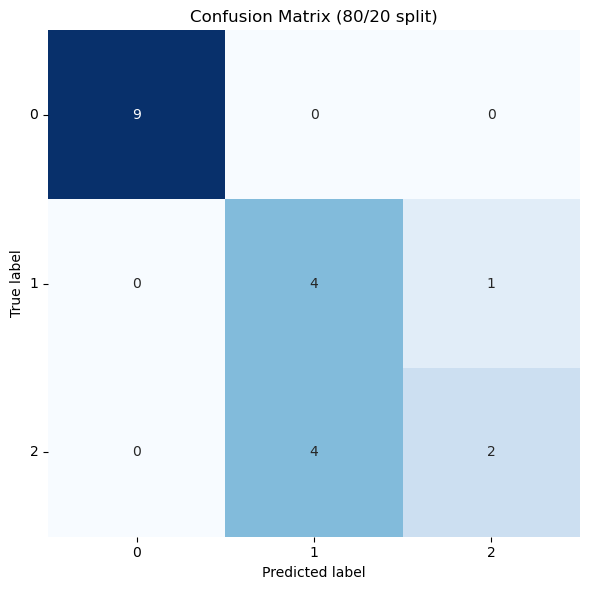

  Seg_17_35076296_35282086   importance: 0.7635 rf_imp
  Seg_3_173645852_176989598  importance: 0.4596 rf_imp
  Seg_17_41458670_41494331   importance: 0.4366 rf_imp
  Seg_17_41062669_41447005   importance: 0.4267 rf_imp
  Seg_17_42648686_42873571   importance: 0.4067 rf_imp
  Seg_3_177004388_181135381  importance: 0.4002 rf_imp
  Seg_17_1542118_1560766     importance: 0.3999 rf_imp
  Seg_17_39280577_40847517   importance: 0.3938 rf_imp
  Seg_3_173247425_173637617  importance: 0.3873 rf_imp
  Seg_3_170472437_173237997  importance: 0.3873 rf_imp


In [13]:
print("best model and settings:\n\n",
      best_row[[
        'fs_method','fs_param',
        'clf__n_estimators','clf__max_depth','clf__min_samples_split',
        'val_accuracy', 'train_accuracy'
      ]])

# — 1) 80/20 split — 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=22
)

# — 2) fit on train —
final_pipe.fit(X_train, y_train)

# — 3) predict on test —
y_pred  = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)

# — 4) compute metrics —
metrics = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='macro'),
    'recall'   : recall_score(y_test, y_pred, average='macro'),
    'f1'       : f1_score(y_test, y_pred, average='macro'),
    'auc'      : roc_auc_score(y_test, y_proba, multi_class='ovr')
}

print("Test‑set performance:")
for name, val in metrics.items():
    print(f"  {name:9s}: {val:.4f}")

# — 5) confusion matrix —
cm = confusion_matrix(y_test, y_pred)
classes = final_pipe.named_steps['clf'].classes_

fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,        # show counts in each cell
    fmt='d',           # integer format
    cmap='Blues',      # you can pick any Seaborn colormap
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
    cbar =False
)

ax.set_title("Confusion Matrix (80/20 split)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



if hasattr(best_fs, 'estimator_') and hasattr(fs.estimator_, 'feature_importances_'):
    # RandomForest importance
    imp = best_fs.estimator_.feature_importances_
    idx = np.argsort(imp)[::-1][:10]
    top10 = [(feature_names[i], imp[i]) for i in idx]
elif hasattr(best_fs, 'components_'):
    # PCA: top 10 features with highest summed absolute loadings
    load = best_fs.components_
    scores = np.sum(np.abs(load), axis=0)
    idx = np.argsort(scores)[::-1][:10]
    top10 = [(feature_names[i], scores[i]) for i in idx]
else:
    # Correlation-based: |corr(feature, y)|
    corrs = X_train.apply(lambda col: np.corrcoef(col, y_train)[0,1]).abs()
    top10 = list(zip(corrs.sort_values(ascending=False).index[:10],
                     corrs.sort_values(ascending=False).values[:10]))

for feat, score in top10:
    print(f"  {feat:25s}  importance: {score:.4f}", best_fs)